In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv(r"D:\PYTHON\DS\loan_data.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y


In [3]:
dataset.shape

(381, 13)

In [4]:
dataset.isnull()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,False,False,False,False,False,False,False,False,False,False,False,False,False
377,False,False,False,False,False,False,False,False,False,False,False,False,False
378,False,False,False,False,False,False,False,False,False,False,False,False,False
379,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
dataset.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
# check overall null value
dataset.isnull().sum().sum()

75

In [7]:
# check per column in parcent null value 
(dataset.isnull().sum()/dataset.shape[0])*100

Loan_ID              0.000000
Gender               1.312336
Married              0.000000
Dependents           2.099738
Education            0.000000
Self_Employed        5.511811
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     2.887139
Credit_History       7.874016
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [8]:
# check overall nul value in parcent 
(dataset.isnull().sum().sum()/(dataset.shape[0]*dataset.shape[1]))*100

1.5142337976983646

In [9]:
# Check total not null value
dataset.notnull().sum().sum()

4878

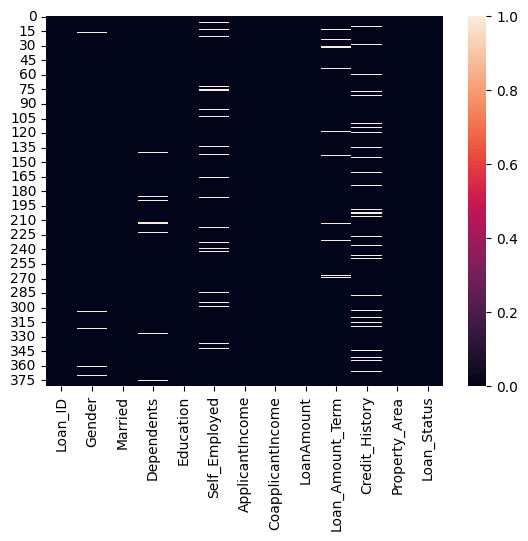

In [10]:
# null value represent in a  graphical  representation.
sns.heatmap(dataset.isnull())
plt.show()

## Handling missng value

##### method 1: Delete particular column
##### method 2: Delete particular Row

In [11]:
# Delete 'Credit_history' column
#dataset.drop(columns=["Credit_History"],inplace=True)

In [12]:
#dataset.shape

In [13]:
#sns.heatmap(dataset.isnull())
#plt.show()

In [14]:
#dataset.dropna(inplace = True)

In [15]:
#dataset.shape

In [16]:
#sns.heatmap(dataset.isnull())
#plt.show()

In [17]:
# Calculate deleted data
#((381-338)/381)*100

#### ===> fill missing value

In [18]:
#dataset.isnull().sum()

In [19]:
#dataset.info()

In [20]:
# fill data using backword method
#dataset.fillna(method = "bfill")

In [21]:
# fill row wise data using forward method
#dataset.fillna(method = "ffill",axis = 0)

In [22]:
#dataset["Gender"].mode()[0]

In [23]:
#dataset["Gender"].fillna(dataset["Gender"].mode()[0],inplace = True)

In [24]:
#dataset.info()

In [25]:
#dataset.select_dtypes(include = "object").isnull().sum()

In [26]:
#dataset.select_dtypes(include = "object").columns

In [27]:
#for i in dataset.select_dtypes(include = "object").columns:
  #  print(i)


In [28]:
#for i in dataset.select_dtypes(include = "object").columns:
 #   dataset[i].fillna(dataset[i].mode()[0], inplace = True)

## Handling Missing values (Scikit-Learn)

In [29]:
#dataset.isnull().sum()

In [30]:
#dataset.info()

In [31]:
dataset.select_dtypes(include = "float64").columns

Index(['CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
       'Credit_History'],
      dtype='object')

In [32]:
from sklearn.impute import SimpleImputer

In [33]:
si = SimpleImputer(strategy = "mean")
ar = si.fit_transform(dataset[['CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
       'Credit_History']])

In [35]:
new_dataset = pd.DataFrame(ar,columns = dataset.select_dtypes(include = "float64").columns)

In [36]:
new_dataset

,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1508.0,128.0,360.0,1.0
1,0.0,66.0,360.0,1.0
2,2358.0,120.0,360.0,1.0
3,0.0,141.0,360.0,1.0
4,1516.0,95.0,360.0,1.0
...,...,...,...,...
376,0.0,128.0,360.0,1.0
377,1950.0,108.0,360.0,1.0
378,0.0,71.0,360.0,1.0
379,0.0,40.0,180.0,1.0


In [37]:
dataset["LoanAmount"].mean()

104.98687664041995